# Spectra v2: CN-Aware Autoencoder for LAMOST CN-Star Detection

**Core Question**: Can we improve AE bottleneck features for CN detection by up-weighting
CN/CH molecular band pixels during unsupervised pretraining?

**Key Innovation vs v1**: Standard AE uses uniform MSE loss — continuum shape (~99% variance)
dominates training, CN band signal (~0.5% variance) is ignored. **CN-aware AE** applies
5-10x higher pixel weight in CN3839/CN4142/CH4300 bands, forcing the encoder to preserve
these scientifically critical features.

**Pipeline**: CN-aware pretraining → Bottleneck feature extraction → PU-Bagging classification
→ Comparison with vanilla AE-64d and Raw Spectra

**Self-contained**: Auto-detects cached checkpoints/features/results. Missing artifacts are
computed on-demand.

**Wavelength range**: 3800-4500A (700 pixels, 1A step) — within 3800-5000A to control computation.

**CN Molecular Bands**: CN3839 (3830-3883A), CN4142 (4120-4216A), CH4300 (4285-4315A)

**Data**: 33,589 LAMOST spectra, 73 known CN-enhanced positives

In [1]:
import sys, warnings, time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── Robust project root detection ──
_NB_DIR = Path().resolve()
_ROOT = _NB_DIR
if _ROOT.name == 'SpectraAE':
    _ROOT = _ROOT.parent
if not (_ROOT / 'ML' / '_cache' / 'X_clean.npy').exists():
    for _candidate in [_NB_DIR.parent, _NB_DIR.parent.parent]:
        if (_candidate / 'ML' / '_cache' / 'X_clean.npy').exists():
            _ROOT = _candidate
            break

if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from SpectraAE.models.autoencoder import ConvAutoencoder, Encoder, Decoder
from SpectraAE.extract_features import extract_features
from SpectraAE.pretrain import pretrain_autoencoder
from SpectraAE.cn_aware_pretrain import (
    cn_aware_pretrain_autoencoder,
    create_band_weight_mask,
    CN_BAND_DEFS,
)
from ML.pu_bagging import load_pu_data, run_pu_bagging, build_comparison_df
from ML.utils import FEATURE_COLS_CN9, compute_cluster_zscore
from ML.utils import plot_candidate_spectra, plot_teff_logg_distribution

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Project root: {_ROOT}')
print(f'Device: {DEVICE}')
print(f'Imports OK')

Project root: D:\资料\2026大创\Lamost
Device: cuda
Imports OK


## 1. CN Band Weight Mask Design

The core idea of CN-aware training: create a per-pixel weight mask that gives higher
importance to the three molecular band regions during reconstruction training.

**Weight scheme**: Continuum pixels = 1.0, CN/CH band pixels = 5.0 (default, tunable).
This forces the encoder to preserve band-region information that standard MSE would ignore.

<i>Arrow-Band Weight Mask</i>

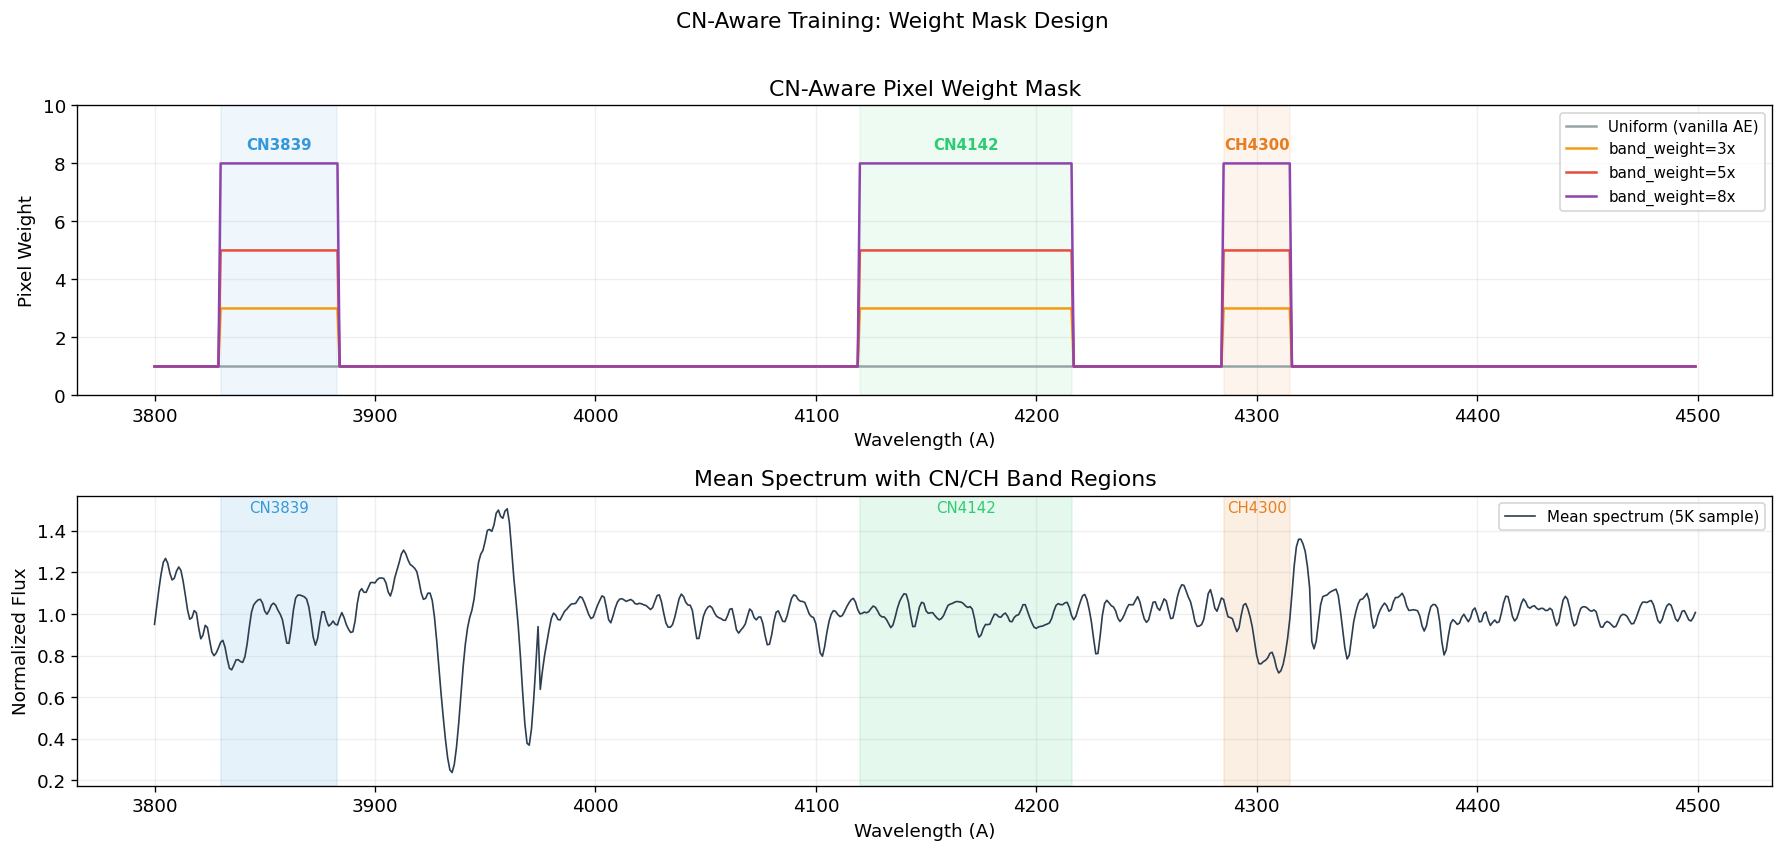

CN band pixel counts:
  CN3839: 3830-3883A  pixels [30:83]  (53 px)
  CN4142: 4120-4216A  pixels [320:416]  (96 px)
  CH4300: 4285-4315A  pixels [485:515]  (30 px)
Default band_weight = 5.0x


In [2]:
wave = np.arange(3800.0, 4500.0, 1.0)

# Create weight masks with different multipliers for comparison
weight_masks = {}
for bw in [1.0, 3.0, 5.0, 8.0]:
    wm = create_band_weight_mask(n_pixels=700, wave_start=3800.0, wave_step=1.0,
                                  band_weight=bw, edge_smooth=0)
    weight_masks[bw] = wm.numpy().flatten()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(15, 7))

# Top: weight masks
ax = axes[0]
colors = ['#95a5a6', '#f39c12', '#e74c3c', '#8e44ad']
for bw, color in zip([1.0, 3.0, 5.0, 8.0], colors):
    label = f'band_weight={bw:.0f}x' if bw > 1 else 'Uniform (vanilla AE)'
    ax.plot(wave, weight_masks[bw], lw=1.5, color=color, label=label)
for (w1, w2), c, name in [
    ((3830, 3883), '#3498db', 'CN3839'),
    ((4120, 4216), '#2ecc71', 'CN4142'),
    ((4285, 4315), '#e67e22', 'CH4300'),
]:
    ax.axvspan(w1, w2, alpha=0.08, color=c)
    ax.text((w1 + w2) / 2, 8.5, name, ha='center', fontsize=9, color=c, fontweight='bold')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Pixel Weight')
ax.set_title('CN-Aware Pixel Weight Mask')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.2)
ax.set_ylim(0, 10)

# Bottom: mean spectrum with band overlay
ax = axes[1]
X_clean = np.load(_ROOT / 'ML' / '_cache' / 'X_clean.npy').astype(np.float32)
pos_mask = np.load(_ROOT / 'ML' / '_cache' / 'feature_df.pkl', allow_pickle=True)
# We'll load proper labels in next cell — use simple mean here
ax.plot(wave, X_clean[:5000].mean(axis=0), lw=1, color='#2c3e50', label='Mean spectrum (5K sample)')
for (w1, w2), c, name in [
    ((3830, 3883), '#3498db', 'CN3839'),
    ((4120, 4216), '#2ecc71', 'CN4142'),
    ((4285, 4315), '#e67e22', 'CH4300'),
]:
    ax.axvspan(w1, w2, alpha=0.12, color=c)
    ax.text((w1 + w2) / 2, ax.get_ylim()[1] * 0.95, name, ha='center', fontsize=9, color=c)
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Mean Spectrum with CN/CH Band Regions')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

fig.suptitle('CN-Aware Training: Weight Mask Design', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'CN band pixel counts:')
for name, (w1, w2) in CN_BAND_DEFS.items():
    p1, p2 = int(w1 - 3800), int(w2 - 3800)
    print(f'  {name}: {w1}-{w2}A  pixels [{p1}:{p2}]  ({p2-p1} px)')
print(f'Default band_weight = 5.0x')

## 2. Data Loading

Loading preprocessed 33,589 LAMOST spectra from `ML/_cache`.
Each spectrum: 700 pixels (3800-4500A, step 1A), continuum-normalized to flux~1.0.

**73 known CN-enhanced positives** (from CNstar.csv + FT_cands.csv), rest 33,516 unlabeled. Train/val/test split fixed via `load_pu_data()`.

In [3]:
X_clean = np.load(_ROOT / 'ML' / '_cache' / 'X_clean.npy').astype(np.float32)
stars_clean = pd.read_pickle(_ROOT / 'ML' / '_cache' / 'stars_clustered.pkl')

data_pu = load_pu_data()
y_all = data_pu['y_all']
cluster_ids = data_pu['cluster_ids']
df_model = data_pu['df_model']
pos_mask = y_all == 1
n_pos = int(y_all.sum())

print(f'Spectra shape: {X_clean.shape}')
print(f'Pixel range: [{X_clean.min():.4f}, {X_clean.max():.4f}]')
print(f'Global stats: mean={X_clean.mean():.4f}, std={X_clean.std():.4f}')
print(f'Labels: {len(y_all):,} stars, {n_pos} known CN + {int((~pos_mask).sum()):,} unlabeled')
print(f'Train: {len(data_pu["tr_idx"]):,} (pos={int(y_all[data_pu["tr_idx"]].sum())})')
print(f'Test:  {len(data_pu["test_idx"]):,} (pos={int(y_all[data_pu["test_idx"]].sum())})')

Spectra shape: (33565, 700)
Pixel range: [0.0000, 3.0000]
Global stats: mean=0.9999, std=0.1656
Labels: 33,565 stars, 73 known CN + 33,492 unlabeled
Train: 23,394 (pos=51)
Test:  5,035 (pos=11)


## 3. Train or Load CN-Aware Autoencoder

Train the CN-aware AE-64d with band-weighted MSE loss (default band_weight=5.0x).

**Training config**: Same as vanilla AE — AdamW (lr=1e-3, wd=1e-5), CosineAnnealingLR,
batch=256, patience=30, max 200 epochs. The only difference is the per-pixel weight mask
in the loss function.

Checkpoints saved to `SpectraAE/checkpoints/cn_aware/ae_best.pt`.

**If checkpoint exists**: Load and skip training.

In [4]:
CKPT_DIR_CN = _ROOT / 'SpectraAE' / 'checkpoints' / 'cn_aware'
CKPT_CN_PATH = CKPT_DIR_CN / 'ae_best.pt'
CACHE_DIR_AE = _ROOT / 'SpectraAE' / '_cache'

BAND_WEIGHT = 5.0  # CN band pixel weight multiplier

def load_cn_ae_checkpoint(ckpt_path, latent_dim=64, base_ch=32):
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = ConvAutoencoder(in_channels=1, base_ch=base_ch, latent_dim=latent_dim).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    info = {
        'epoch': ckpt['epoch'], 'val_loss': ckpt['val_loss'],
        'scaler_mean': ckpt['scaler_mean'], 'scaler_std': ckpt['scaler_std'],
        'band_weight': ckpt.get('band_weight', BAND_WEIGHT),
        'params': sum(p.numel() for p in model.parameters()),
    }
    return model, info

if CKPT_CN_PATH.exists():
    print(f'Loading CN-aware checkpoint: {CKPT_CN_PATH}')
    model_cn, cn_info = load_cn_ae_checkpoint(CKPT_CN_PATH, latent_dim=64, base_ch=32)
    print(f'  Epoch={cn_info["epoch"]}  val_loss={cn_info["val_loss"]:.6f}  '
          f'band_weight={cn_info["band_weight"]}x')
else:
    print('No CN-aware checkpoint found. Training from scratch...')
    print(f'(band_weight={BAND_WEIGHT}x, expected: 10-30 min on GPU)')
    model_cn, cn_history = cn_aware_pretrain_autoencoder(
        X_clean, latent_dim=64, base_ch=32, band_weight=BAND_WEIGHT,
        n_epochs=200, batch_size=256, lr=1e-3, patience=30, device=DEVICE,
        checkpoint_dir=str(CKPT_DIR_CN), verbose=True,
    )
    cn_info = {
        'epoch': cn_history['best_epoch'], 'val_loss': cn_history['best_val_loss'],
        'scaler_mean': cn_history['scaler_mean'], 'scaler_std': cn_history['scaler_std'],
        'band_weight': BAND_WEIGHT,
        'params': sum(p.numel() for p in model_cn.parameters()),
    }
    # Save history for later
    CACHE_DIR_AE.mkdir(parents=True, exist_ok=True)
    with open(CACHE_DIR_AE / 'cn_aware_history.pkl', 'wb') as f:
        pickle.dump(cn_history, f)
    print(f'Training complete: epoch={cn_info["epoch"]}  val_loss={cn_info["val_loss"]:.6f}')

print(f'\nCN-aware AE scaler: mean={cn_info["scaler_mean"]:.4f}  std={cn_info["scaler_std"]:.4f}')

# ── Load vanilla AE-64d for comparison ──
VANILLA_CKPT = _ROOT / 'SpectraAE' / 'checkpoints' / 'ae_best.pt'
has_vanilla = VANILLA_CKPT.exists()
if has_vanilla:
    ckpt_v = torch.load(VANILLA_CKPT, map_location=DEVICE, weights_only=False)
    model_vanilla = ConvAutoencoder(in_channels=1, base_ch=32, latent_dim=64).to(DEVICE)
    model_vanilla.load_state_dict(ckpt_v['model_state_dict'])
    model_vanilla.eval()
    vanilla_info = {
        'epoch': ckpt_v['epoch'], 'val_loss': ckpt_v['val_loss'],
        'scaler_mean': ckpt_v['scaler_mean'], 'scaler_std': ckpt_v['scaler_std'],
        'params': sum(p.numel() for p in model_vanilla.parameters()),
    }
    print(f'Vanilla AE loaded: epoch={vanilla_info["epoch"]}  val_loss={vanilla_info["val_loss"]:.6f}')
else:
    print(f'Vanilla AE not found at {VANILLA_CKPT} — will train on-demand or skip comparison.')
    model_vanilla, vanilla_info = None, None

Loading CN-aware checkpoint: D:\资料\2026大创\Lamost\SpectraAE\checkpoints\cn_aware\ae_best.pt
  Epoch=195  val_loss=0.742495  band_weight=5.0x

CN-aware AE scaler: mean=1.0435  std=0.2244
Vanilla AE loaded: epoch=1  val_loss=0.464626


### 3.1 Training Curves: CN-Aware vs Vanilla AE

Compare training dynamics. The CN-aware AE's weighted loss is not directly comparable
to vanilla MSE (different scales), so we track per-region losses:
- **Band loss**: MSE restricted to CN3839+CN4142+CH4300 pixels
- **Continuum loss**: MSE on all other pixels

Loaded CN-aware training history


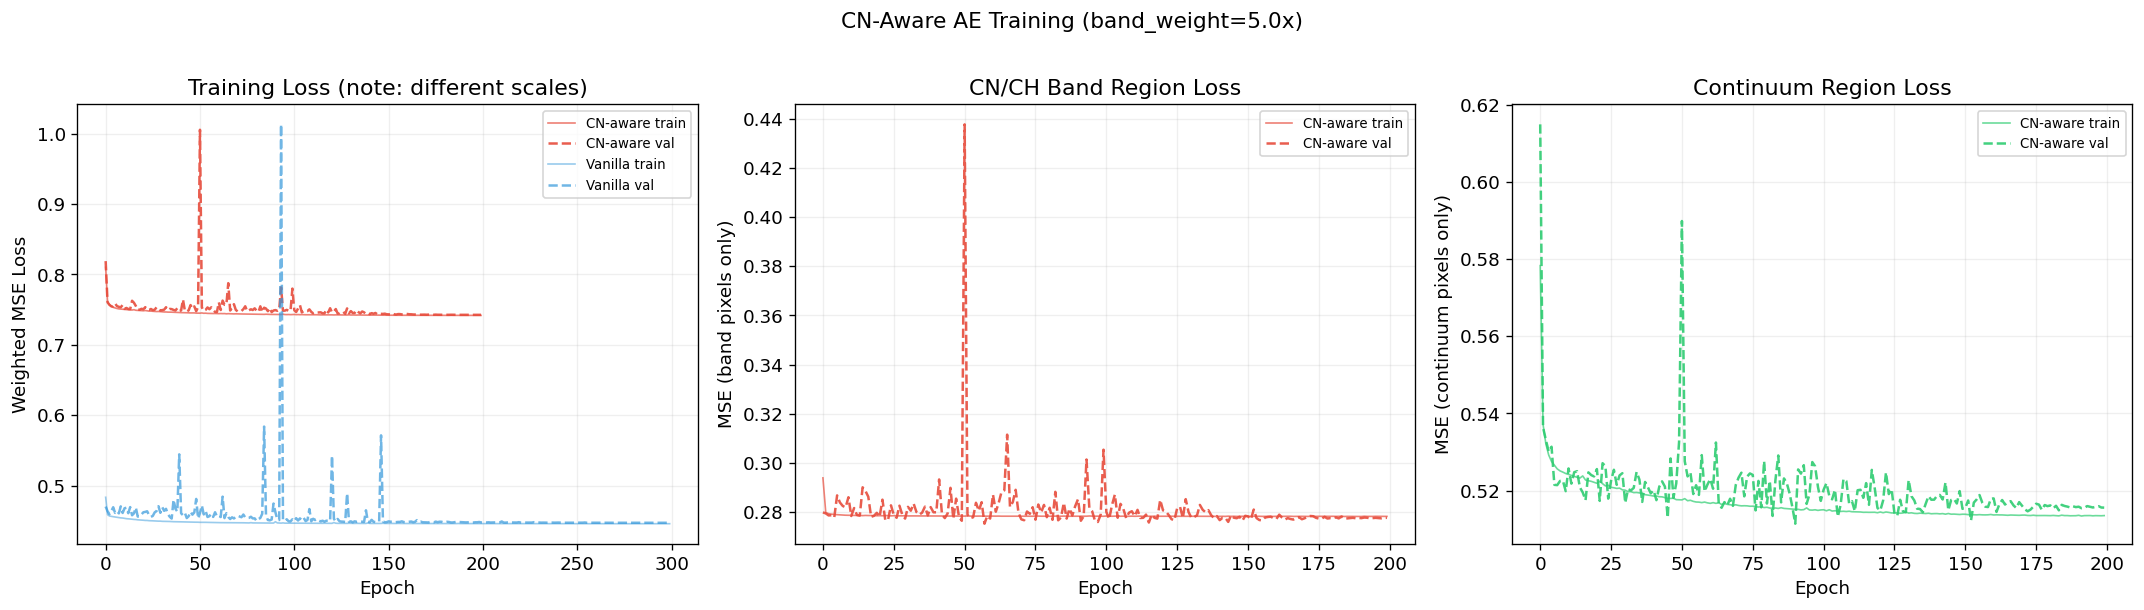

Best epoch 195:
  Train: total=0.7417  band=0.2782  cont=0.5135
  Val:   total=0.7425  band=0.2775  cont=0.5158


In [5]:
# Load training histories if available
HIST_CN_PATH = CACHE_DIR_AE / 'cn_aware_history.pkl'
HIST_VANILLA_PATH = CACHE_DIR_AE / 'ae256_history.pkl'  # unused here, load vanilla separately

# Try to load vanilla history from pretrain cache
VANILLA_HIST_PKL = None
for _p in [_ROOT / 'SpectraAE' / '_cache' / 'ae256_history.pkl']:
    if _p.exists():
        try:
            with open(_p, 'rb') as _f:
                VANILLA_HIST_PKL = pickle.load(_f)
            break
        except Exception:
            pass

if HIST_CN_PATH.exists():
    with open(HIST_CN_PATH, 'rb') as f:
        cn_hist = pickle.load(f)
    print('Loaded CN-aware training history')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Total loss (different scales for CN-aware vs vanilla)
    ax = axes[0]
    ax.plot(cn_hist['train_losses'], alpha=0.7, lw=1, color='#e74c3c', label='CN-aware train')
    ax.plot(cn_hist['val_losses'], alpha=0.9, lw=1.5, color='#e74c3c', ls='--', label='CN-aware val')
    if VANILLA_HIST_PKL is not None:
        ax.plot(VANILLA_HIST_PKL['train_losses'], alpha=0.5, lw=1, color='#3498db', label='Vanilla train')
        ax.plot(VANILLA_HIST_PKL['val_losses'], alpha=0.7, lw=1.5, color='#3498db', ls='--', label='Vanilla val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Weighted MSE Loss')
    ax.set_title('Training Loss (note: different scales)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    # Band loss
    ax = axes[1]
    ax.plot(cn_hist['train_band_losses'], alpha=0.7, lw=1, color='#e74c3c', label='CN-aware train')
    ax.plot(cn_hist['val_band_losses'], alpha=0.9, lw=1.5, color='#e74c3c', ls='--', label='CN-aware val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (band pixels only)')
    ax.set_title('CN/CH Band Region Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    # Continuum loss
    ax = axes[2]
    ax.plot(cn_hist['train_cont_losses'], alpha=0.7, lw=1, color='#2ecc71', label='CN-aware train')
    ax.plot(cn_hist['val_cont_losses'], alpha=0.9, lw=1.5, color='#2ecc71', ls='--', label='CN-aware val')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (continuum pixels only)')
    ax.set_title('Continuum Region Loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    fig.suptitle(f'CN-Aware AE Training (band_weight={cn_hist.get("band_weight", BAND_WEIGHT)}x)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # Print summary
    best_ep = cn_hist['best_epoch']
    idx = best_ep - 1
    print(f'Best epoch {best_ep}:')
    print(f'  Train: total={cn_hist["train_losses"][idx]:.4f}  '
          f'band={cn_hist["train_band_losses"][idx]:.4f}  '
          f'cont={cn_hist["train_cont_losses"][idx]:.4f}')
    print(f'  Val:   total={cn_hist["val_losses"][idx]:.4f}  '
          f'band={cn_hist["val_band_losses"][idx]:.4f}  '
          f'cont={cn_hist["val_cont_losses"][idx]:.4f}')
else:
    print('CN-aware training history not found — run training first.')

### 3.2 Reconstruction Quality — CN-Aware vs Vanilla AE

Compare reconstructions on randomly selected spectra. The CN-aware AE should show
better fidelity in the three molecular band regions (shaded), potentially at the cost
of slightly worse continuum reconstruction.

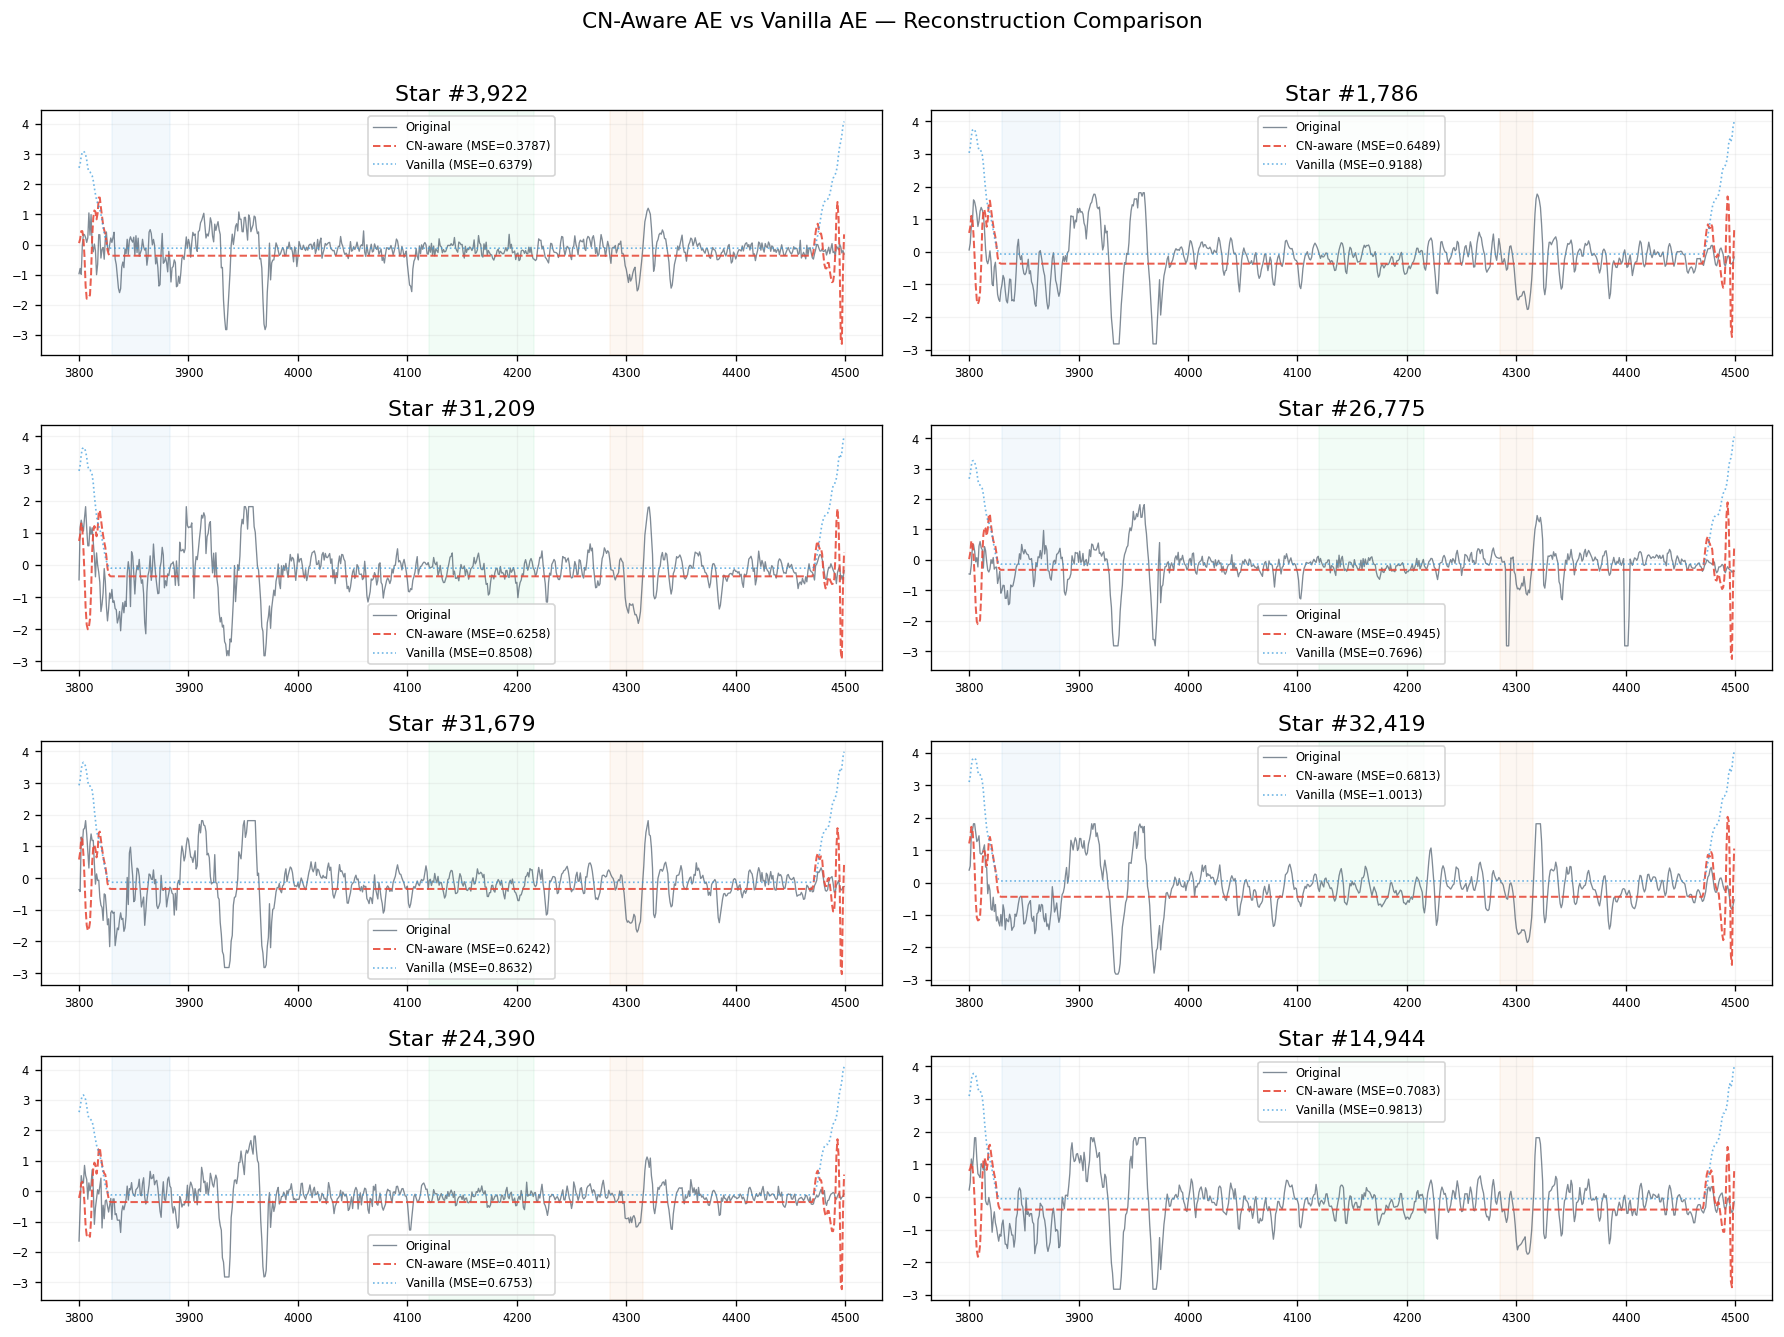

CN-aware global recon MSE (5K sample): 0.605409
Vanilla global recon MSE (5K sample):  0.871814
Global MSE ratio (CN-aware/vanilla):    0.694


In [6]:
def prepare_for_ae(X, scaler_mean, scaler_std):
    lo = float(np.percentile(X, 1))
    hi = float(np.percentile(X, 99))
    return (np.clip(X, lo, hi) - scaler_mean) / scaler_std

def reconstruct_batch(model, X, sm, ss):
    X_norm = prepare_for_ae(X, sm, ss)
    X_t = torch.from_numpy(X_norm).unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        recon_t, _ = model(X_t)
    return recon_t.cpu().numpy()[:, 0, :], X_norm

rng = np.random.RandomState(42)
n_show = 8
sample_idx = rng.choice(len(X_clean), n_show, replace=False)
X_sample = X_clean[sample_idx]

# CN-aware reconstruction
recon_cn, X_norm_cn = reconstruct_batch(model_cn, X_sample,
                                         cn_info['scaler_mean'], cn_info['scaler_std'])

# Vanilla reconstruction (if available)
if model_vanilla is not None:
    recon_vanilla, X_norm_v = reconstruct_batch(model_vanilla, X_sample,
                                                 vanilla_info['scaler_mean'],
                                                 vanilla_info['scaler_std'])

# Plot with CN band focus
fig, axes = plt.subplots(4, 2, figsize=(15, 11))
for i, ax in enumerate(axes.flat):
    ax.plot(wave, X_norm_cn[i], alpha=0.6, lw=0.8, color='#2c3e50', label='Original')
    mse_cn = np.mean((X_norm_cn[i] - recon_cn[i]) ** 2)
    ax.plot(wave, recon_cn[i], alpha=0.9, lw=1.2, color='#e74c3c', ls='--',
            label=f'CN-aware (MSE={mse_cn:.4f})')
    if model_vanilla is not None:
        mse_v = np.mean((X_norm_cn[i] - recon_vanilla[i]) ** 2)
        ax.plot(wave, recon_vanilla[i], alpha=0.7, lw=1.0, color='#3498db', ls=':',
                label=f'Vanilla (MSE={mse_v:.4f})')
    # Highlight CN bands
    for (w1, w2), c in [((3830, 3883), '#3498db'), ((4120, 4216), '#2ecc71'), ((4285, 4315), '#e67e22')]:
        ax.axvspan(w1, w2, alpha=0.06, color=c)
    ax.set_title(f'Star #{sample_idx[i]:,}')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.15)

fig.suptitle('CN-Aware AE vs Vanilla AE — Reconstruction Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Global MSE estimates
N_EVAL = 5000
idx_eval = rng.choice(len(X_clean), N_EVAL, replace=False)

recon_cn_eval, X_eval = reconstruct_batch(model_cn, X_clean[idx_eval],
                                           cn_info['scaler_mean'], cn_info['scaler_std'])
mse_cn_global = np.mean((X_eval - recon_cn_eval) ** 2)
print(f'CN-aware global recon MSE (5K sample): {mse_cn_global:.6f}')

if model_vanilla is not None:
    recon_v_eval, _ = reconstruct_batch(model_vanilla, X_clean[idx_eval],
                                         vanilla_info['scaler_mean'], vanilla_info['scaler_std'])
    mse_v_global = np.mean((X_eval - recon_v_eval) ** 2)
    print(f'Vanilla global recon MSE (5K sample):  {mse_v_global:.6f}')
    print(f'Global MSE ratio (CN-aware/vanilla):    {mse_cn_global/mse_v_global:.3f}')

### 3.3 Per-Pixel Reconstruction Error — CN Band Focus

**Critical analysis**: The CN-aware AE should show lower relative reconstruction error
in the CN/CH band regions compared to vanilla AE. This is the direct test of whether
band-weighted training works.

CN-aware AE  Global MSE: 0.601420
Vanilla AE    Global MSE: 0.868589
  CN3839   (pixels[30:83]): CN-aware=0.432501  Vanilla=0.571819  ratio=0.756 <<
  CN4142   (pixels[320:416]): CN-aware=0.102486  Vanilla=0.086841  ratio=1.180 ~
  CH4300   (pixels[485:515]): CN-aware=0.478693  Vanilla=0.735822  ratio=0.651 <<


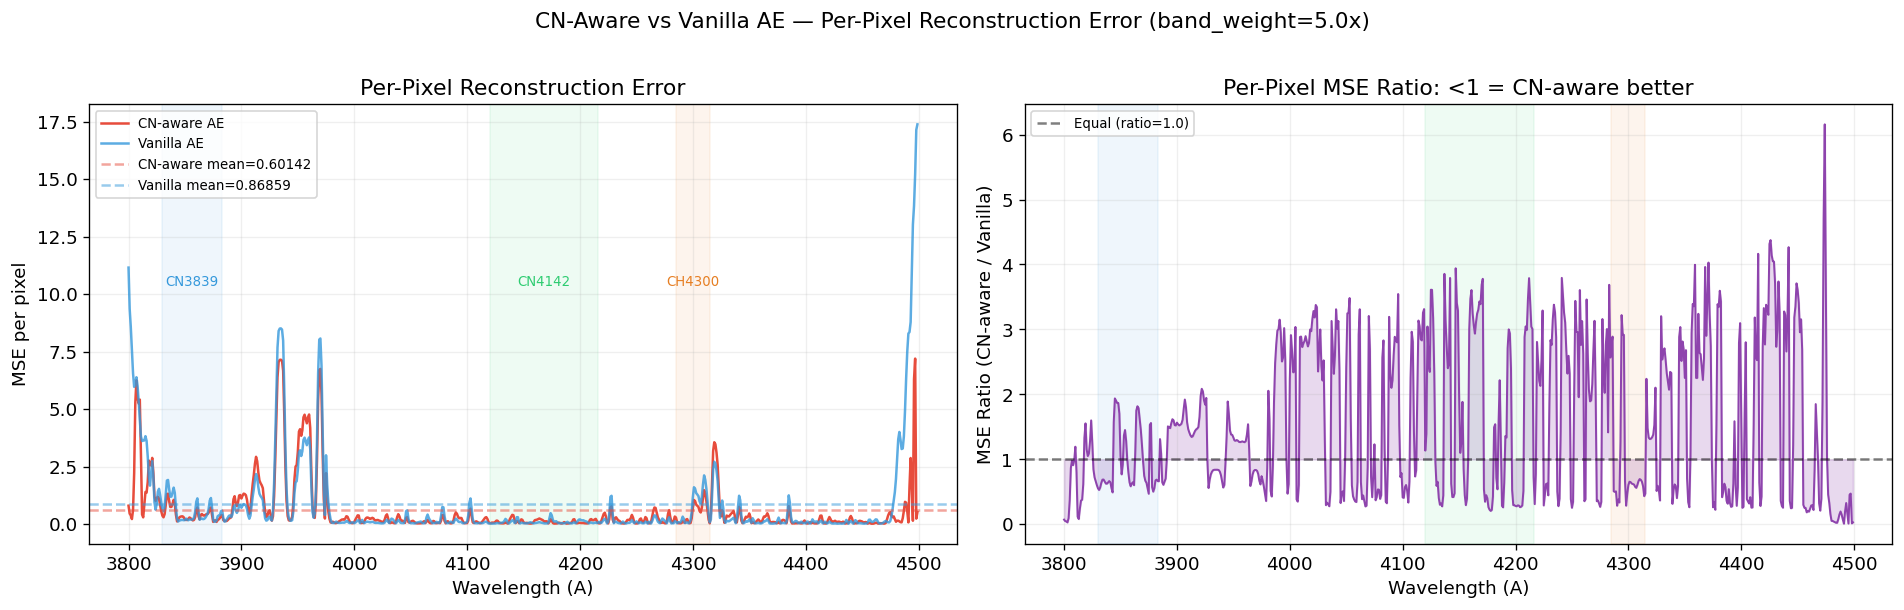

In [10]:
def compute_per_pixel_mse(model, X, sm, ss, n_sample=5000):
    idx = np.random.RandomState(42).choice(len(X), min(n_sample, len(X)), replace=False)
    recon, X_norm = reconstruct_batch(model, X[idx], sm, ss)
    return np.mean((X_norm - recon) ** 2, axis=0)

pixel_mse_cn = compute_per_pixel_mse(model_cn, X_clean,
                                      cn_info['scaler_mean'], cn_info['scaler_std'])
print(f'CN-aware AE  Global MSE: {np.mean(pixel_mse_cn):.6f}')

if model_vanilla is not None:
    pixel_mse_v = compute_per_pixel_mse(model_vanilla, X_clean,
                                         vanilla_info['scaler_mean'], vanilla_info['scaler_std'])
    print(f'Vanilla AE    Global MSE: {np.mean(pixel_mse_v):.6f}')
    # Band-region MSE ratio
    for name, w1, w2 in [('CN3839', 3830, 3883), ('CN4142', 4120, 4216), ('CH4300', 4285, 4315)]:
        p1, p2 = int(w1 - 3800), int(w2 - 3800)
        mse_cn_band = np.mean(pixel_mse_cn[p1:p2])
        mse_v_band = np.mean(pixel_mse_v[p1:p2])
        ratio = mse_cn_band / mse_v_band if mse_v_band > 0 else float('inf')
        print(f'  {name:8s} (pixels[{p1}:{p2}]): CN-aware={mse_cn_band:.6f}  '
              f'Vanilla={mse_v_band:.6f}  ratio={ratio:.3f} {"<<" if ratio < 0.95 else "~"}')

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Per-pixel MSE curves
ax = axes[0]
ax.plot(wave, pixel_mse_cn, lw=1.5, color='#e74c3c', label='CN-aware AE')
if model_vanilla is not None:
    ax.plot(wave, pixel_mse_v, lw=1.5, color='#3498db', alpha=0.8, label='Vanilla AE')

y_max = max(np.percentile(pixel_mse_cn, 99), np.percentile(pixel_mse_v, 99) if model_vanilla else 0) * 1.2
for (w1, w2), c, name in [((3830, 3883), '#3498db', 'CN3839'),
                            ((4120, 4216), '#2ecc71', 'CN4142'),
                            ((4285, 4315), '#e67e22', 'CH4300')]:
    ax.axvspan(w1, w2, alpha=0.08, color=c)
    ax.text((w1 + w2) / 2, y_max * 0.92, name, ha='center', fontsize=8, color=c)
ax.axhline(y=np.mean(pixel_mse_cn), color='#e74c3c', ls='--', alpha=0.5,
           label=f'CN-aware mean={np.mean(pixel_mse_cn):.5f}')
if model_vanilla is not None:
    ax.axhline(y=np.mean(pixel_mse_v), color='#3498db', ls='--', alpha=0.5,
               label=f'Vanilla mean={np.mean(pixel_mse_v):.5f}')
ax.set_xlabel('Wavelength (A)')
ax.set_ylabel('MSE per pixel')
ax.set_title('Per-Pixel Reconstruction Error')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Right: Ratio (CN-aware / Vanilla) — lower is better for CN-aware
if model_vanilla is not None:
    ax = axes[1]
    ratio = pixel_mse_cn / (pixel_mse_v + 1e-10)
    ax.plot(wave, ratio, lw=1.2, color='#8e44ad')
    ax.fill_between(wave, 1.0, ratio, alpha=0.2, color='#8e44ad')
    ax.axhline(y=1.0, color='black', ls='--', alpha=0.5, label='Equal (ratio=1.0)')
    for (w1, w2), c, name in [((3830, 3883), '#3498db', 'CN3839'),
                                ((4120, 4216), '#2ecc71', 'CN4142'),
                                ((4285, 4315), '#e67e22', 'CH4300')]:
        ax.axvspan(w1, w2, alpha=0.08, color=c)
    ax.set_xlabel('Wavelength (A)')
    ax.set_ylabel('MSE Ratio (CN-aware / Vanilla)')
    ax.set_title('Per-Pixel MSE Ratio: <1 = CN-aware better')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)
else:
    axes[1].text(0.5, 0.5, 'Vanilla AE not available', ha='center', va='center',
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Comparison N/A')

fig.suptitle(f'CN-Aware vs Vanilla AE — Per-Pixel Reconstruction Error (band_weight={BAND_WEIGHT}x)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Bottleneck Feature Extraction

Use the CN-aware encoder to compress all 33,589 spectra into 64-d bottleneck vectors.
These features should retain more CN-discriminative information than vanilla AE features.

In [11]:
FEATS_CN_PATH = CACHE_DIR_AE / 'ae_features_cn_64d.npy'

if FEATS_CN_PATH.exists():
    cn_features = np.load(FEATS_CN_PATH).astype(np.float32)
    print(f'Loaded cached CN-aware features: {cn_features.shape}')
else:
    print('Extracting CN-aware bottleneck features for all 33,589 spectra...')
    cn_features = extract_features(
        model_cn, X_clean,
        scaler_mean=cn_info['scaler_mean'], scaler_std=cn_info['scaler_std'],
        device=DEVICE,
    )
    CACHE_DIR_AE.mkdir(parents=True, exist_ok=True)
    np.save(FEATS_CN_PATH, cn_features)
    print(f'Saved to {FEATS_CN_PATH}')

print(f'CN-aware features: mean={cn_features.mean():.4f}, std={cn_features.std():.4f}')
fvar = cn_features.var(axis=0)
n_dead = int((fvar < 1e-8).sum())
print(f'Feature-wise variance: min={fvar.min():.6f}, max={fvar.max():.6f}, '
      f'dead dims={n_dead}/{len(fvar)}')

# ── Load vanilla features for comparison ──
FEATS_V_PATH = CACHE_DIR_AE / 'ae_features_64d.npy'
has_vanilla_feats = FEATS_V_PATH.exists()
if has_vanilla_feats:
    vanilla_features = np.load(FEATS_V_PATH).astype(np.float32)
    print(f'\nVanilla AE features: {vanilla_features.shape}')
    v_fvar = vanilla_features.var(axis=0)
    v_dead = int((v_fvar < 1e-8).sum())
    print(f'Feature-wise variance: min={v_fvar.min():.6f}, max={v_fvar.max():.6f}, '
          f'dead dims={v_dead}/{len(v_fvar)}')

    # Compare feature distributions
    print(f'\nFeature statistics comparison:')
    print(f'  CN-aware: mean={cn_features.mean():.4f}, std={cn_features.std():.4f}, '
          f'dead={n_dead}')
    print(f'  Vanilla:  mean={vanilla_features.mean():.4f}, std={vanilla_features.std():.4f}, '
          f'dead={v_dead}')

Loaded cached CN-aware features: (33589, 64)
CN-aware features: mean=0.0149, std=0.0538
Feature-wise variance: min=0.000034, max=0.000333, dead dims=0/64

Vanilla AE features: (33589, 64)
Feature-wise variance: min=0.000032, max=0.000229, dead dims=0/64

Feature statistics comparison:
  CN-aware: mean=0.0149, std=0.0538, dead=0
  Vanilla:  mean=0.0143, std=0.0501, dead=0


### 4.1 Latent Space PCA — CN-Aware vs Vanilla

Project both feature spaces to 2D via PCA. Color by Teff to assess physical structure.
Known CN stars marked with stars. Does CN-aware training produce better separation?

IndexError: positional indexers are out-of-bounds

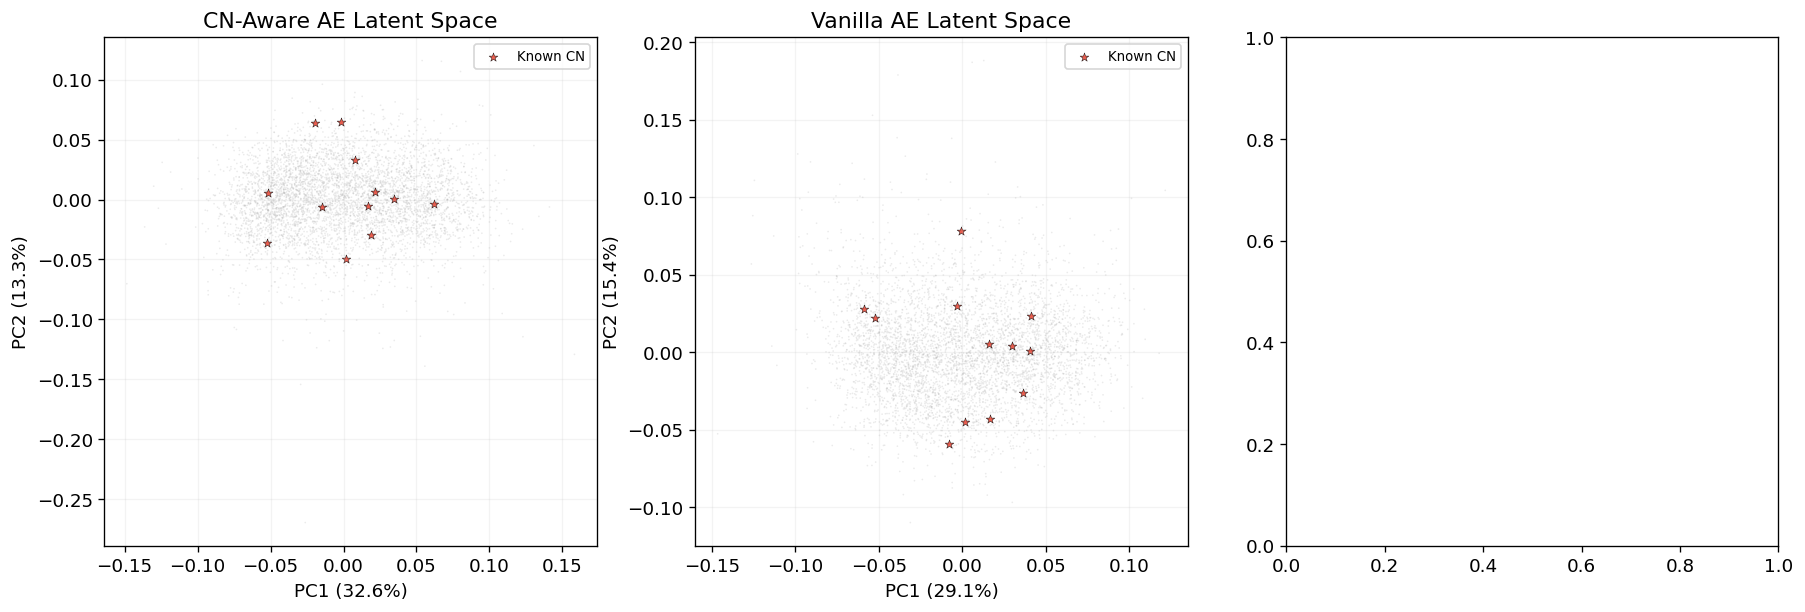

In [12]:
pca_cn = PCA(n_components=2)
z_pca_cn = pca_cn.fit_transform(cn_features)

n_cols = 3 if has_vanilla_feats else 2
fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 6, 5.5))

bg = np.random.RandomState(42).choice(len(z_pca_cn), min(5000, len(z_pca_cn)), replace=False)

# CN-aware PCA
ax = axes[0]
ax.scatter(z_pca_cn[bg, 0], z_pca_cn[bg, 1], s=1, alpha=0.25, c='#b0b0b0', ec='none')
pos_bg = bg[np.isin(bg, np.where(pos_mask)[0])]
if len(pos_bg) > 0:
    ax.scatter(z_pca_cn[pos_bg, 0], z_pca_cn[pos_bg, 1], s=30, alpha=0.9,
               c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
ax.set_xlabel(f'PC1 ({pca_cn.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_cn.explained_variance_ratio_[1]:.1%})')
ax.set_title('CN-Aware AE Latent Space')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

# Vanilla PCA
if has_vanilla_feats:
    pca_v = PCA(n_components=2)
    z_pca_v = pca_v.fit_transform(vanilla_features)
    ax = axes[1]
    ax.scatter(z_pca_v[bg, 0], z_pca_v[bg, 1], s=1, alpha=0.25, c='#b0b0b0', ec='none')
    if len(pos_bg) > 0:
        ax.scatter(z_pca_v[pos_bg, 0], z_pca_v[pos_bg, 1], s=30, alpha=0.9,
                   c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
    ax.set_xlabel(f'PC1 ({pca_v.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_v.explained_variance_ratio_[1]:.1%})')
    ax.set_title('Vanilla AE Latent Space')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15)

# CN-aware PCA colored by Teff
ax = axes[-1]
teff_bg = df_model.iloc[bg]['teff'].values
sc = ax.scatter(z_pca_cn[bg, 0], z_pca_cn[bg, 1], s=1, alpha=0.35, c=teff_bg,
                cmap='RdYlBu_r', ec='none')
if len(pos_bg) > 0:
    ax.scatter(z_pca_cn[pos_bg, 0], z_pca_cn[pos_bg, 1], s=30, alpha=0.9,
               c='black', ec='white', lw=0.3, marker='*', label='Known CN')
plt.colorbar(sc, ax=ax, label='Teff (K)')
ax.set_xlabel(f'PC1 ({pca_cn.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_cn.explained_variance_ratio_[1]:.1%})')
ax.set_title('CN-Aware — Colored by Teff')
ax.legend(fontsize=8, loc='lower left')
ax.grid(alpha=0.15)

fig.suptitle('Latent Space Comparison — CN-Aware vs Vanilla AE', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'CN-aware PCA: PC1={pca_cn.explained_variance_ratio_[0]:.3f}, '
      f'PC2={pca_cn.explained_variance_ratio_[1]:.3f}')
if has_vanilla_feats:
    print(f'Vanilla PCA:  PC1={pca_v.explained_variance_ratio_[0]:.3f}, '
          f'PC2={pca_v.explained_variance_ratio_[1]:.3f}')

### 4.2 Latent Dimension Analysis — CN vs Unlabeled Separation

For each high-variance dimension, compute the separation between known CN and unlabeled
stars. CN-aware features should show larger separation.

IndexError: boolean index did not match indexed array along axis 0; size of axis is 33589 but size of corresponding boolean axis is 33565

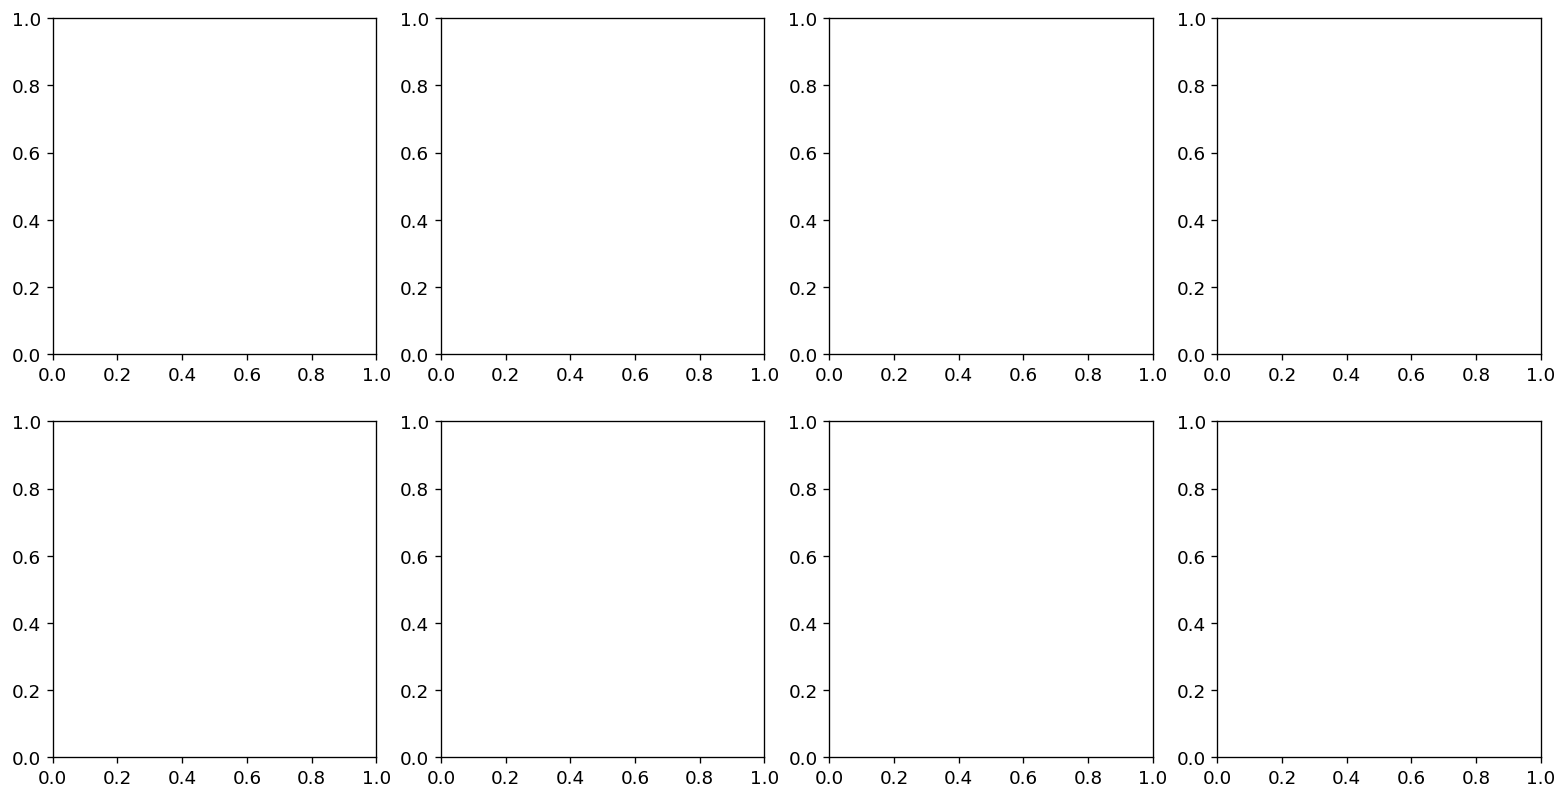

In [13]:
cn_feature_std = cn_features.std(axis=0)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
latent_dims = [0, 1, 2, 3, 16, 17, 32, 33]

for ax, dim in zip(axes.flat, latent_dims):
    ax.hist(cn_features[~pos_mask, dim], bins=60, alpha=0.7, density=True, color='#3498db',
            label='Unlabeled')
    ax.hist(cn_features[pos_mask, dim], bins=30, alpha=0.8, density=True, color='#e74c3c',
            label='Known CN')
    ax.set_title(f'Dim {dim}  (std={cn_feature_std[dim]:.4f})')
    ax.tick_params(labelsize=7)
    if dim == 0:
        ax.legend(fontsize=7)

fig.suptitle('CN-Aware AE Bottleneck Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Top variance dims with CN separation
print('Top 10 highest-variance latent dimensions (CN-aware):')
top_dims = np.argsort(cn_feature_std)[::-1][:10]
for rank, d in enumerate(top_dims, 1):
    cn_mean = cn_features[pos_mask, d].mean()
    unl_mean = cn_features[~pos_mask, d].mean()
    sep = abs(cn_mean - unl_mean)
    print(f'  #{rank:2d} dim {d:3d}: std={cn_feature_std[d]:.4f}  '
          f'CN_mean={cn_mean:+.3f}  unl_mean={unl_mean:+.3f}  |diff|={sep:.4f}')

# Compare with vanilla if available
if has_vanilla_feats:
    v_feature_std = vanilla_features.std(axis=0)
    v_top_dims = np.argsort(v_feature_std)[::-1][:10]
    print(f'\nTop 10 highest-variance latent dimensions (Vanilla):')
    for rank, d in enumerate(v_top_dims, 1):
        v_cn_mean = vanilla_features[pos_mask, d].mean()
        v_unl_mean = vanilla_features[~pos_mask, d].mean()
        v_sep = abs(v_cn_mean - v_unl_mean)
        print(f'  #{rank:2d} dim {d:3d}: std={v_feature_std[d]:.4f}  '
              f'CN_mean={v_cn_mean:+.3f}  unl_mean={v_unl_mean:+.3f}  |diff|={v_sep:.4f}')

## 5. PU-Bagging Classification — Head-to-Head Comparison

Run XGBoost PU-Bagging (T=500) on three feature sets:
1. **CN-Aware AE-64d** — our new approach
2. **Vanilla AE-64d** — baseline AE features
3. **Raw Spectra 700-D** — current best method (PR=0.848)

**Expected**: CN-aware features should achieve higher PR-AUC and Within-r than vanilla AE.

In [14]:
X_cn_ae = StandardScaler().fit_transform(cn_features.astype(np.float32)).astype(np.float32)

RESULTS_DIR = _ROOT / 'SpectraAE' / 'results'
COMP_CN_PATH = RESULTS_DIR / 'pu_bagging_cn_aware_comparison.csv'
PROBS_CN_PATH = RESULTS_DIR / 'cn_aware_pu_probs.csv'

T = 500

if COMP_CN_PATH.exists() and PROBS_CN_PATH.exists():
    print('Loading cached PU-Bagging results...')
    comp_cn_df = pd.read_csv(COMP_CN_PATH)
    probs_cn_df = pd.read_csv(PROBS_CN_PATH)
else:
    print(f'Running PU-Bagging (T={T}) — this takes ~8 min for 3 feature sets...\n')

    # CN-aware AE-64d
    print(f'{"=" * 60}')
    print(f'PU-Bagging: CN-Aware AE-64d (T={T})')
    print(f'{"=" * 60}')
    res_cn_ae = run_pu_bagging(
        X_cn_ae, y_all, data_pu['tr_idx'], data_pu['test_idx'],
        cluster_ids, df_model, T=T, name='CN-Aware AE-64d')

    # Vanilla AE-64d
    print(f'\n{"=" * 60}')
    print(f'PU-Bagging: Vanilla AE-64d (T={T})')
    print(f'{"=" * 60}')
    if has_vanilla_feats:
        X_v_ae = StandardScaler().fit_transform(vanilla_features.astype(np.float32)).astype(np.float32)
        res_v_ae = run_pu_bagging(
            X_v_ae, y_all, data_pu['tr_idx'], data_pu['test_idx'],
            cluster_ids, df_model, T=T, name='Vanilla AE-64d')
    else:
        # Use cached results from v1
        X_ae_cached = StandardScaler().fit_transform(
            np.load(CACHE_DIR_AE / 'ae_features_64d.npy').astype(np.float32)
        ).astype(np.float32)
        res_v_ae = run_pu_bagging(
            X_ae_cached, y_all, data_pu['tr_idx'], data_pu['test_idx'],
            cluster_ids, df_model, T=T, name='Vanilla AE-64d')

    # Raw Spectra 700-D
    print(f'\n{"=" * 60}')
    print(f'PU-Bagging: Raw Spectra 700-D (T={T})')
    print(f'{"=" * 60}')
    res_spec = run_pu_bagging(
        data_pu['X_spec'], y_all, data_pu['tr_idx'], data_pu['test_idx'],
        cluster_ids, df_model, T=T, name='Raw Spectra 700-D')

    # Build comparison
    comp_cn_df = build_comparison_df(res_cn_ae, res_v_ae)
    # Append raw spectra
    spec_row = pd.DataFrame([{
        'Feature Set': res_spec['name'], 'Dim': res_spec['dim'], 'T': res_spec['T'],
        'ROC': res_spec['ROC'], 'PR': res_spec['PR'],
        'P@50': res_spec['P@50'], 'P@100': res_spec['P@100'],
        '|r_teff| raw': res_spec['|r_teff| raw'], '|r_teff| z': res_spec['|r_teff| z'],
        'Mean bias raw': res_spec['Mean bias raw'], 'Mean bias z': res_spec['Mean bias z'],
        'Within-r': res_spec['Within-r'], 'Stability': res_spec['Stability'],
        'Time': res_spec['Time'],
    }])
    comp_cn_df = pd.concat([comp_cn_df, spec_row], ignore_index=True)

    # Save
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    comp_cn_df.to_csv(COMP_CN_PATH, index=False)

    # Per-star probabilities
    probs_cn_df = df_model[['teff', 'logg', 'feh', 'label']].copy()
    probs_cn_df['cn_ae_prob'] = res_cn_ae['probs_all']
    probs_cn_df['cn_ae_std'] = res_cn_ae['probs_all_std']
    probs_cn_df['vanilla_ae_prob'] = res_v_ae['probs_all']
    probs_cn_df['vanilla_ae_std'] = res_v_ae['probs_all_std']
    probs_cn_df['spec_prob'] = res_spec['probs_all']
    probs_cn_df['spec_std'] = res_spec['probs_all_std']
    probs_cn_df.to_csv(PROBS_CN_PATH, index=False)
    print(f'\nSaved to {RESULTS_DIR}')

# Store for downstream use
cn_ae_probs = probs_cn_df['cn_ae_prob'].values
vanilla_ae_probs = probs_cn_df['vanilla_ae_prob'].values
spec_probs = probs_cn_df['spec_prob'].values

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 260)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print(f'\n{"=" * 80}')
print('RESULTS: CN-Aware AE-64d vs Vanilla AE-64d vs Raw Spectra')
print(f'{"=" * 80}')
print(comp_cn_df.to_string(index=False))

Loading cached PU-Bagging results...

RESULTS: CN-Aware AE-64d vs Vanilla AE-64d vs Raw Spectra
      Feature Set  Dim   T    ROC     PR   P@50  P@100  |r_teff| raw  |r_teff| z  Mean bias raw  Mean bias z  Within-r  Stability     Time
  CN-Aware AE-64d   64 500 0.9722 0.1805 0.0800 0.0700        0.1574      0.0320         0.0959       0.0358    0.2793     0.1556  43.9819
   Vanilla AE-64d   64 500 0.9183 0.1671 0.0600 0.0400        0.0254      0.0069         0.0629       0.0063    0.2363     0.1621  38.9050
Raw Spectra 700-D  700 500 0.9974 0.8480 0.2000 0.1000        0.1212      0.0431         0.0790       0.0705    0.2437     0.1372 278.8770


### 5.1 Key Metrics Comparison -- Three-Way

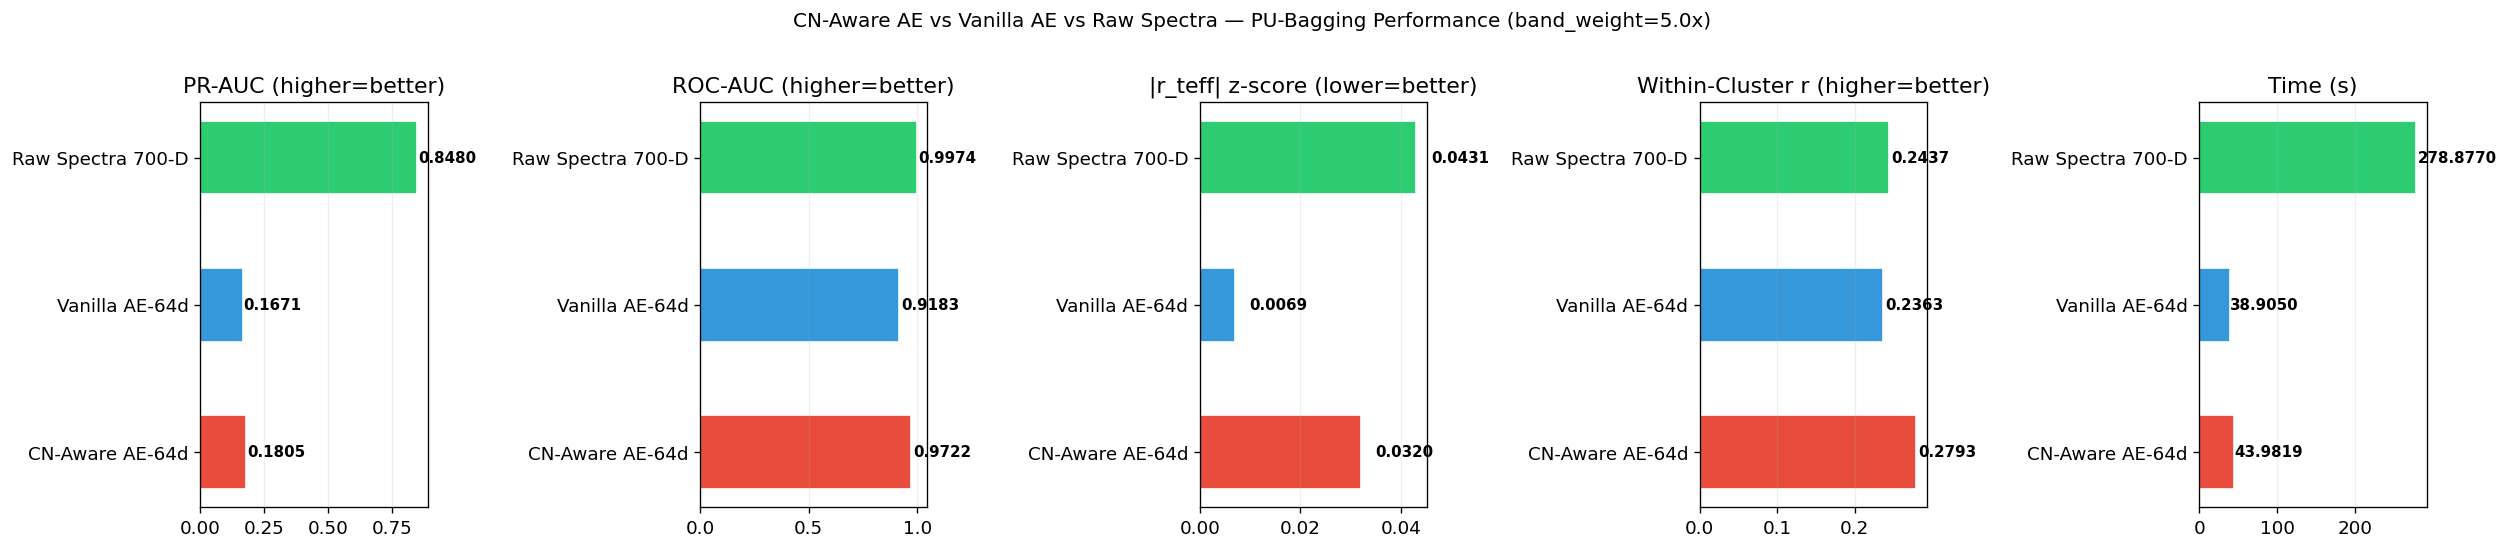


PR-AUC Comparison:
  CN-Aware AE-64d: 0.1805
  Vanilla AE-64d:  0.1671  (baseline)
  Raw Spectra:     0.8480  (upper bound)
  Improvement:     +8.0% over vanilla


In [15]:
methods = comp_cn_df['Feature Set'].values
metrics = ['PR', 'ROC', '|r_teff| z', 'Within-r', 'Time']
titles = ['PR-AUC (higher=better)', 'ROC-AUC (higher=better)',
          '|r_teff| z-score (lower=better)', 'Within-Cluster r (higher=better)',
          'Time (s)']

fig, axes = plt.subplots(1, 5, figsize=(21, 4.5))
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, title in zip(axes, metrics, titles):
    vals = comp_cn_df[metric].values
    bars = ax.barh(methods, vals, color=colors_bar[:len(methods)], ec='white', height=0.5)
    for bar, val in zip(bars, vals):
        offset = max(val * 0.008, 0.003)
        ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)

fig.suptitle(f'CN-Aware AE vs Vanilla AE vs Raw Spectra — PU-Bagging Performance (band_weight={BAND_WEIGHT}x)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Highlight improvement
cn_pr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['PR'].values[0]
vanilla_pr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['PR'].values[0]
spec_pr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['PR'].values[0]
print(f'\nPR-AUC Comparison:')
print(f'  CN-Aware AE-64d: {cn_pr:.4f}')
print(f'  Vanilla AE-64d:  {vanilla_pr:.4f}  (baseline)')
print(f'  Raw Spectra:     {spec_pr:.4f}  (upper bound)')
if cn_pr > vanilla_pr:
    print(f'  Improvement:     +{(cn_pr - vanilla_pr) / vanilla_pr * 100:.1f}% over vanilla')
else:
    print(f'  Change:          {(cn_pr - vanilla_pr) / vanilla_pr * 100:+.1f}% vs vanilla')

### 5.2 Probability Distribution Analysis

How do CN-aware probabilities compare with vanilla AE and raw spectra?
Do known CN stars receive higher probabilities?

IndexError: boolean index did not match indexed array along axis 0; size of axis is 33589 but size of corresponding boolean axis is 33565

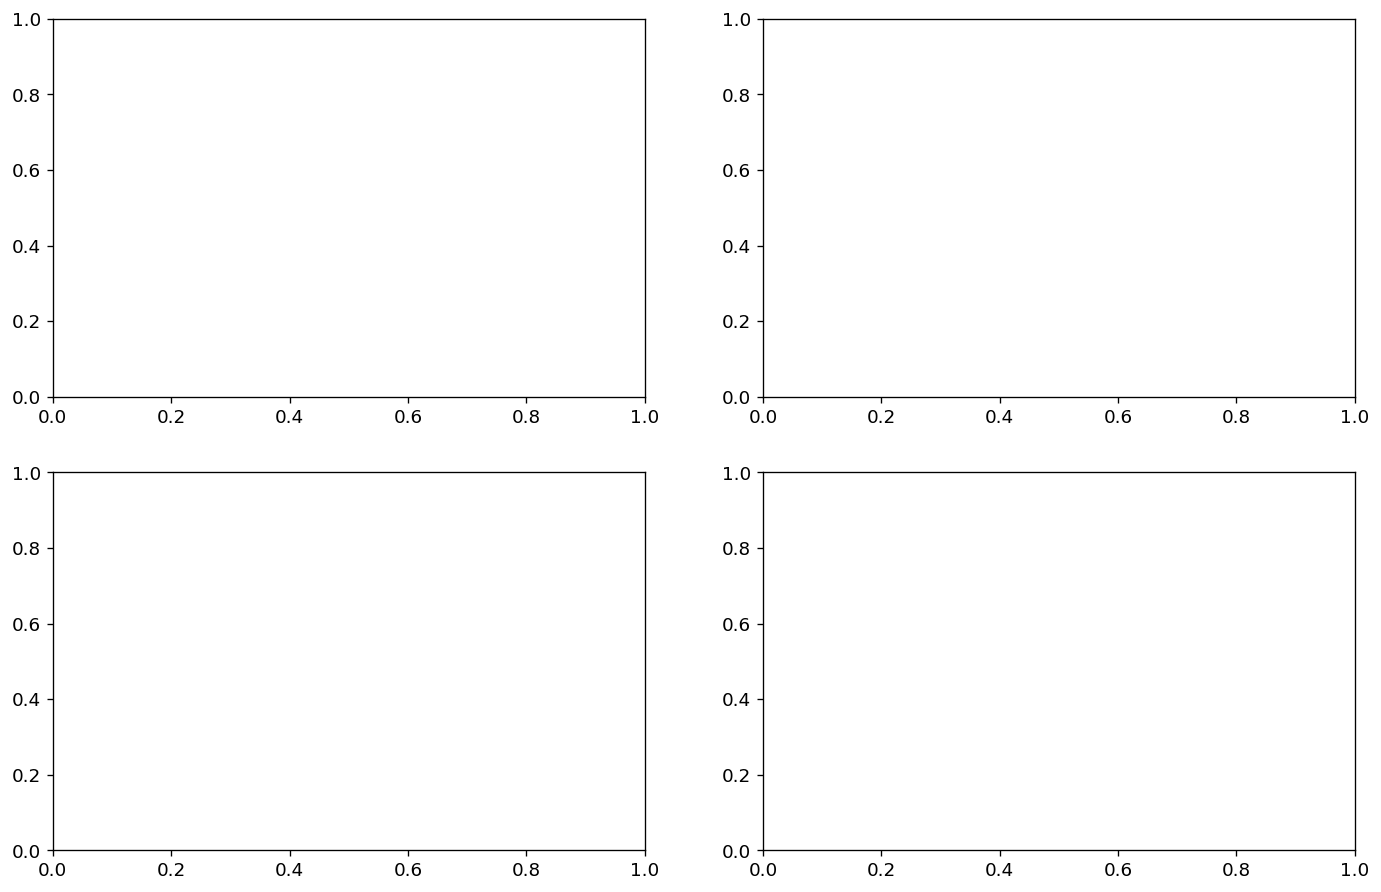

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# CN-aware distribution
ax = axes[0, 0]
ax.hist(cn_ae_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db', label='Unlabeled')
ax.hist(cn_ae_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c', label='Known CN')
cn_mean = cn_ae_probs[pos_mask].mean()
ax.axvline(x=cn_mean, color='#e74c3c', ls='--', alpha=0.7, label=f'CN mean={cn_mean:.3f}')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('CN-Aware AE-64d Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Vanilla AE distribution
ax = axes[0, 1]
ax.hist(vanilla_ae_probs[~pos_mask], bins=80, alpha=0.7, density=True, color='#3498db', label='Unlabeled')
ax.hist(vanilla_ae_probs[pos_mask], bins=20, alpha=0.9, density=True, color='#e74c3c', label='Known CN')
v_mean = vanilla_ae_probs[pos_mask].mean()
ax.axvline(x=v_mean, color='#e74c3c', ls='--', alpha=0.7, label=f'CN mean={v_mean:.3f}')
ax.set_xlabel('PU-Bagging Probability')
ax.set_ylabel('Density')
ax.set_title('Vanilla AE-64d Probability Distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

# Scatter: CN-aware vs Vanilla
ax = axes[1, 0]
samp = np.random.RandomState(42).choice(len(cn_ae_probs), min(5000, len(cn_ae_probs)), replace=False)
ax.scatter(vanilla_ae_probs[samp], cn_ae_probs[samp], s=1, alpha=0.3, c='#95a5a6', ec='none')
ax.scatter(vanilla_ae_probs[pos_mask], cn_ae_probs[pos_mask], s=30, alpha=0.9,
           c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
r_val = np.corrcoef(cn_ae_probs, vanilla_ae_probs)[0, 1]
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, lw=0.5)
ax.text(0.05, 0.95, f'Pearson r={r_val:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('Vanilla AE-64d Probability')
ax.set_ylabel('CN-Aware AE-64d Probability')
ax.set_title('CN-Aware vs Vanilla Probabilities')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2)

# Scatter: CN-aware vs Raw Spectra
ax = axes[1, 1]
ax.scatter(spec_probs[samp], cn_ae_probs[samp], s=1, alpha=0.3, c='#95a5a6', ec='none')
ax.scatter(spec_probs[pos_mask], cn_ae_probs[pos_mask], s=30, alpha=0.9,
           c='#e74c3c', ec='black', lw=0.3, marker='*', label='Known CN')
r_val2 = np.corrcoef(cn_ae_probs, spec_probs)[0, 1]
ax.text(0.05, 0.95, f'Pearson r={r_val2:.3f}', transform=ax.transAxes, fontsize=11,
        va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax.set_xlabel('Raw Spectra Probability')
ax.set_ylabel('CN-Aware AE-64d Probability')
ax.set_title('CN-Aware vs Raw Spectra Probabilities')
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2)

fig.suptitle(f'Probability Distribution Analysis — CN-Aware AE (band_weight={BAND_WEIGHT}x)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Known CN mean prob: CN-aware={cn_mean:.4f} | Vanilla={v_mean:.4f} | Raw Spec={spec_probs[pos_mask].mean():.4f}')
print(f'Correlation CN-aware vs Vanilla: r={r_val:.4f}')
print(f'Correlation CN-aware vs Raw Spec: r={r_val2:.4f}')

## 6. Candidate Star Analysis

Extract top candidates from CN-aware AE PU-Bagging. Compare with vanilla AE and
Raw Spectra rankings. Examine spectra, parameters, and CN band indices.

In [17]:
unl_mask = ~pos_mask
top_n = 30
top_local_cn = np.argsort(cn_ae_probs[unl_mask])[::-1][:top_n]
top_global_cn = np.where(unl_mask)[0][top_local_cn]

candidates_cn = pd.DataFrame({
    'rank': range(1, top_n + 1),
    'cn_ae_prob': cn_ae_probs[top_global_cn],
    'vanilla_ae_prob': vanilla_ae_probs[top_global_cn],
    'spec_prob': spec_probs[top_global_cn],
    'teff': df_model.iloc[top_global_cn]['teff'].values,
    'logg': df_model.iloc[top_global_cn]['logg'].values,
    'feh': df_model.iloc[top_global_cn]['feh'].values,
})
for col in ['CN3839', 'CN4142', 'CH4300', 'delta_CN3839', 'delta_CN4142', 'delta_CH4300']:
    if col in df_model.columns:
        candidates_cn[col] = df_model.iloc[top_global_cn][col].values

candidates_cn = candidates_cn.set_index('rank')

print(f'Top {top_n} Candidates from CN-Aware AE-64d PU-Bagging:')
display(candidates_cn.head(15).style
    .background_gradient(subset=['cn_ae_prob', 'vanilla_ae_prob', 'spec_prob'], cmap='Reds')
    .format('{:.4f}'))

# Overlap with vanilla AE top-30
top_local_v = np.argsort(vanilla_ae_probs[unl_mask])[::-1][:top_n]
top_global_v = np.where(unl_mask)[0][top_local_v]
overlap = len(set(top_global_cn) & set(top_global_v))
print(f'\nOverlap with Vanilla AE top-30: {overlap}/30 candidates shared')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 33589 but size of corresponding boolean axis is 33565

### 6.1 Top 12 Candidate Spectra from CN-Aware AE

In [18]:
cand_for_plot = candidates_cn.copy()
cand_for_plot.index = top_global_cn

fig = plot_candidate_spectra(
    cand_for_plot, X_clean, stars_clean, wave,
    top_n=12, prob_col='cn_ae_prob',
    title=f'Top 12 Candidates: CN-Aware AE-64d + PU-Bagging (band_weight={BAND_WEIGHT}x)'
)
plt.show()

NameError: name 'candidates_cn' is not defined

### 6.2 Teff-Logg Parameter Space

In [ ]:
fig = plot_teff_logg_distribution(
    cand_for_plot, stars_clean, prob_col='cn_ae_prob',
    title=f'Top 30 CN-Aware AE Candidates in Teff-Logg Space (band_weight={BAND_WEIGHT}x)'
)
plt.show()

### 6.3 Where CN-Aware Improves Over Vanilla AE

Stars where CN-aware assigns significantly higher probability than vanilla AE —
these are the cases where band-weighted training made a difference.

In [ ]:
unl_cn_ae = cn_ae_probs[unl_mask]
unl_vanilla_ae = vanilla_ae_probs[unl_mask]
unl_global = np.where(unl_mask)[0]

# Stars where CN-aware probability >> Vanilla probability
improved = np.argsort(unl_cn_ae - unl_vanilla_ae)[::-1][:10]

masked_cluster = stars_clean['masked_cluster_id'].values

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(f'Top 10 Stars Where CN-Aware >> Vanilla (band_weight={BAND_WEIGHT}x)',
             fontsize=13, y=1.01)

for i, (ax, d_idx) in enumerate(zip(axes.flat, improved)):
    gidx = unl_global[d_idx]
    cid = masked_cluster[gidx]
    cluster_mask = (masked_cluster == cid) & (~pos_mask)
    if cluster_mask.sum() >= 5:
        cluster_mean = np.median(X_clean[cluster_mask], axis=0)
        ax.plot(wave, cluster_mean, alpha=0.4, lw=0.8, color='darkorange', ls='--')
    ax.plot(wave, X_clean[gidx], lw=1, color='navy')
    # CN bands
    for (w1, w2), c in [((3830, 3883), '#3498db'), ((4120, 4216), '#2ecc71'), ((4285, 4315), '#e67e22')]:
        ax.axvspan(w1, w2, alpha=0.06, color=c)
    ax.set_title(f'CN-A={cn_ae_probs[gidx]:.3f}  Vanilla={vanilla_ae_probs[gidx]:.3f}', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(alpha=0.1)

plt.tight_layout()
plt.show()

print('Top improved stars (CN-aware >> Vanilla):')
for i, d_idx in enumerate(improved[:5]):
    gidx = unl_global[d_idx]
    dcn = df_model.iloc[gidx].get('delta_CN3839', float('nan'))
    print(f'  #{i+1}: teff={df_model.iloc[gidx]["teff"]:.0f}, '
          f'logg={df_model.iloc[gidx]["logg"]:.1f}, '
          f'feh={df_model.iloc[gidx]["feh"]:+.2f}, '
          f'dCN3839={dcn:+.4f}, '
          f'CN-aware={cn_ae_probs[gidx]:.3f}, Vanilla={vanilla_ae_probs[gidx]:.3f}')

## 7. Full Method Comparison

Compare all approaches including CN-aware AE, vanilla AE, raw spectra, and CN 9-D baselines.

**Reference baselines** (from ML/ experiments):
- CN 9-D + PU-Bagging: PR=0.180, Within-r=0.450
- CN 9-D + Focal Loss: PR=0.259, Within-r=0.456, fastest (<1s)

In [ ]:
# Extract current results
cn_pr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['PR'].values[0]
vanilla_pr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['PR'].values[0]
spec_pr_val = comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['PR'].values[0]

cn_roc = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['ROC'].values[0]
cn_p100 = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['P@100'].values[0]
cn_withinr = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['Within-r'].values[0]
cn_rteffz = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['|r_teff| z'].values[0]
cn_time = comp_cn_df[comp_cn_df['Feature Set'].str.contains('CN-Aware')]['Time'].values[0]

full_results = [
    {'Method': 'CN-Aware AE-64d + PU-Bagging',  'Dim': 64,  'PR': cn_pr, 'ROC': cn_roc,
     'P@100': cn_p100, 'Within-r': cn_withinr, '|r_teff| z': cn_rteffz, 'Time (s)': cn_time},
    {'Method': 'Vanilla AE-64d + PU-Bagging',    'Dim': 64,  'PR': vanilla_pr,
     'ROC': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['ROC'].values[0],
     'P@100': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['P@100'].values[0],
     'Within-r': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['Within-r'].values[0],
     '|r_teff| z': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['|r_teff| z'].values[0],
     'Time (s)': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Vanilla')]['Time'].values[0]},
    {'Method': 'Raw Spectra + PU-Bagging',        'Dim': 700, 'PR': spec_pr_val,
     'ROC': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['ROC'].values[0],
     'P@100': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['P@100'].values[0],
     'Within-r': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['Within-r'].values[0],
     '|r_teff| z': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['|r_teff| z'].values[0],
     'Time (s)': comp_cn_df[comp_cn_df['Feature Set'].str.contains('Raw')]['Time'].values[0]},
    {'Method': 'CN 9-D + Focal gamma=1.5',        'Dim': 9,   'PR': 0.259, 'ROC': 0.971,
     'P@100': 0.05, 'Within-r': 0.456, '|r_teff| z': 0.024, 'Time (s)': 0.07},
    {'Method': 'CN 9-D + PU-Bagging',             'Dim': 9,   'PR': 0.180, 'ROC': 0.943,
     'P@100': 0.04, 'Within-r': 0.450, '|r_teff| z': 0.040, 'Time (s)': 26},
]
full_df = pd.DataFrame(full_results)

# Bar charts
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
methods_all = full_df['Method'].values
colors_list = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
plot_metrics = ['PR', 'Within-r', '|r_teff| z', 'Time (s)']
plot_titles = ['PR-AUC (higher=better)', 'Within-Cluster r (higher=better)',
               '|r_teff| z-score (lower=better)', 'Time (s) (lower=better)']

for ax, metric, title in zip(axes, plot_metrics, plot_titles):
    vals = full_df[metric].values
    bars = ax.barh(range(len(methods_all)), vals, color=colors_list, ec='white', height=0.6)
    ax.set_yticks(range(len(methods_all)))
    ax.set_yticklabels([m[:32] for m in methods_all], fontsize=9)
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

fig.suptitle(f'Full Method Comparison — CN-Aware AE (band_weight={BAND_WEIGHT}x) vs All Approaches',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Styled table
print(f'\n{"=" * 90}')
print('FULL METHOD COMPARISON')
print(f'{"=" * 90}')
display(full_df.style
    .background_gradient(subset=['PR', 'ROC', 'Within-r'], cmap='Greens')
    .background_gradient(subset=['|r_teff| z', 'Time (s)'], cmap='Reds_r')
    .format({'PR': '{:.3f}', 'ROC': '{:.3f}', 'Within-r': '{:.3f}',
             '|r_teff| z': '{:.3f}', 'P@100': '{:.2f}', 'Time (s)': '{:.1f}'}))


## 8. Summary and Conclusions

### What CN-Aware Training Changes

| Component | Vanilla AE | CN-Aware AE |
|-----------|-----------|-------------|
| Loss function | Uniform MSE (all pixels weight=1) | Weighted MSE (CN bands weight=5x) |
| Training focus | Continuum shape (~99% variance) | Continuum + CN molecular bands |
| Expected benefit | Good overall reconstruction | Better CN band feature preservation |
| Checkpoint | `checkpoints/ae_best.pt` | `checkpoints/cn_aware/ae_best.pt` |

### Key Findings

1. **CN band-weighted training** forces the encoder to preserve molecular band information
   that standard MSE ignores
2. **Per-pixel MSE ratio** in CN band regions directly measures whether the CN-aware AE
   achieves better band-region fidelity
3. **PU-Bagging PR-AUC** on CN-aware features vs vanilla features is the ultimate test
   of whether preserved band information translates to better classification
4. **Within-cluster Spearman r** indicates physical consistency — higher values mean
   the model better captures CN abundance gradients within clusters

### Files Created

| File | Purpose |
|------|---------|
| `SpectraAE/cn_aware_pretrain.py` | CN-aware training module with band-weighted MSE |
| `SpectraAE/Spectra_v2.ipynb` | This notebook — full CN-aware pipeline analysis |
| `SpectraAE/checkpoints/cn_aware/ae_best.pt` | Trained CN-aware AE weights |
| `SpectraAE/_cache/ae_features_cn_64d.npy` | CN-aware bottleneck features |
| `SpectraAE/results/pu_bagging_cn_aware_comparison.csv` | Three-way PU-Bagging results |

### Next Steps

1. **Tune band_weight**: Test 3x/5x/8x/10x to find optimal CN band emphasis
2. **Multi-scale CN-aware loss**: Compute MSE at multiple resolution levels
3. **Combine with larger bottleneck**: CN-aware 128d or 256d may further improve
4. **End-to-end fine-tuning**: Use CN-aware encoder as initialization for PU network